In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os
package_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "Modules"))
sys.path.append(package_dir)

from clean_dataframe.preprocessing import dtype16

Previous Notebook: `\Cleaning Scripts\2023-03-10 Additional Author Cleaning.ipynb`

In [7]:
# import papers_df
papers_df = pd.read_pickle('2023-03-23_NB4_papers_df_part3.pkl')

In [8]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16679 entries, 0 to 16678
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   first_auth       16679 non-null  object 
 1   second_auth      16679 non-null  object 
 2   third_auth       16679 non-null  object 
 3   Cites            16679 non-null  int64  
 4   ManuscriptTitle  16679 non-null  object 
 5   Year             16679 non-null  int16  
 6   GSRank           16679 non-null  int64  
 7   ECC              16679 non-null  int64  
 8   CitesPerYear     16679 non-null  float64
 9   CitesPerAuthor   16679 non-null  int64  
 10  AuthorCount      16679 non-null  int64  
 11  query_id         16679 non-null  int16  
 12  PubTitle         16679 non-null  object 
 13  PubType          16679 non-null  object 
 14  SJR              16679 non-null  float64
 15  H index          16679 non-null  float16
 16  Country          16679 non-null  object 
 17  Region      

In [9]:
papers_df.head(3)

,first_auth,second_auth,third_auth,Cites,ManuscriptTitle,Year,GSRank,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id,PubTitle,PubType,SJR,H index,Country,Region,query_author
0,d shi,v adinolfi,r comin,4186,Low trapstate density and long carrier diffusi...,2015,1,4186,523.25,523,8,0,science,journal,14.589,1229.0,United States,Northern America,eh sargent
1,h tan,a jain,o voznyy,1951,Efficient and stable solutionprocessed planar ...,2017,4,1951,325.17,279,7,0,science,journal,14.589,1229.0,United States,Northern America,eh sargent
2,bo zhang,x zheng,o voznyy,1756,Homogeneously dispersed multimetal oxygenevolv...,2016,7,1756,250.86,251,7,0,science,journal,14.589,1229.0,United States,Northern America,eh sargent


First, join the `papers_df` to the `query_df`

Need to find a way to cluster the individual authors

Need to expand the data set so that it has the form...


|Name |Title| ...|
|-----|--------|----|
|d shi|low trap-state density and| ...|
|v adinolfi	 |low trap-state density and| ...|
|r comin |low trap-state density and| ...|
|h tan	| efficient and stable solution-| ...|

In [10]:
def make_df(row):
    '''
    
    Parameters:
    ----------
    row: a Pandas Series that is a single row in the larger papers_df data frame. This row should contain
    information about the paper, including the columns 'first_auth', 'second_auth', 'third_auth'.
    
    Return:
    -------
    ret_df: a new data frame that has repeated information about each paper for each author. 
    It also has new columns 'AuthorName' and 'AuthorRank'
    
    '''
    
    # NumpPy Array of the author names
    auth_list = np.unique(row[['first_auth', 'second_auth', 'third_auth', 'query_author']].values)
    
    # Series of values exlcuding the first, second and third author columns
    new_ser = row.drop(['first_auth', 'second_auth', 'third_auth', 'query_author'])
    
    # Initiate a New Data Fame
    ret_df = pd.DataFrame()
    
    # Adding new rows to the data frame for each author in the paper
    for i in range(auth_list.shape[0]):
        auth_ser = pd.Series({'AuthorName': auth_list[i], 'AuthorRank': i+1})
        concat_ser = pd.concat([auth_ser, new_ser])
        
        concat_df = pd.DataFrame([concat_ser])
        ret_df = pd.concat([ret_df, concat_df], axis = 0)
    
    return ret_df

In [12]:
from tqdm.notebook import tqdm 

# Initiate DataFrame
new_df = pd.DataFrame()

# Adding new data frames (this takes about 4-5 minutes)
# Using a for loop instead of .apply() to be able to use the tqdm module to track the progress
for i in tqdm(range(papers_df.shape[0])):
    row = papers_df.loc[i, :]
    
    # Make a new set of dataframe
    ret_df = make_df(row)
     
    # Add to new df
    new_df = pd.concat([new_df, ret_df], axis = 0)

  0%|          | 0/16679 [00:00<?, ?it/s]

In [24]:
new_df = new_df.reset_index(drop = True)

In [128]:
papers_df = new_df
papers_df.to_pickle('2023-03-23_NB5_papers_df.pkl')

In [25]:
rows, cols = new_df.shape
print(f'The new_df has {rows} rows and {cols} columns')

The new_df has 59691 rows and 17 columns


In [26]:
new_df.sample(3)

,AuthorName,AuthorRank,Cites,ManuscriptTitle,Year,GSRank,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id,PubTitle,PubType,SJR,H index,Country,Region
34864,eb riley,1,20,Fabrication and characterization of highqualit...,2012,15,20,1.82,3,8,127,ieee photonics technology letters,journal,0.753,161.0,United States,Northern America
57876,d velsquez,2,24,Computational design of twodimensional nanomat...,2017,34,24,4.00,8,3,125,energy storage materials,journal,4.865,103.0,Netherlands,Western Europe
12388,sj ko,3,222,Role of organic counterion in leadand tinbased...,2016,7,222,31.71,25,9,52,chemistry of materials,journal,2.930,393.0,United States,Northern America


Now that we have the new data frame, we can more easily build a profile for each author.

In [27]:
num_df = new_df.groupby('AuthorName').size().reset_index(name='NumPapers_inDataset')
num_df

,AuthorName,NumPapers_inDataset
0,a aatiq,1
1,a abate,149
2,a abbas,2
3,a abbasi,1
4,a abdollahi,1
...,...,...
16397,zy xia,1
16398,zy xiao,1
16399,zy zhan,1
16400,zz dai,1


In [28]:
new_df.head(5)

,AuthorName,AuthorRank,Cites,ManuscriptTitle,Year,GSRank,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id,PubTitle,PubType,SJR,H index,Country,Region
0,d shi,1,4186,Low trapstate density and long carrier diffusi...,2015,1,4186,523.25,523,8,0,science,journal,14.589,1229.0,United States,Northern America
1,eh sargent,2,4186,Low trapstate density and long carrier diffusi...,2015,1,4186,523.25,523,8,0,science,journal,14.589,1229.0,United States,Northern America
2,r comin,3,4186,Low trapstate density and long carrier diffusi...,2015,1,4186,523.25,523,8,0,science,journal,14.589,1229.0,United States,Northern America
3,v adinolfi,4,4186,Low trapstate density and long carrier diffusi...,2015,1,4186,523.25,523,8,0,science,journal,14.589,1229.0,United States,Northern America
4,a jain,1,1951,Efficient and stable solutionprocessed planar ...,2017,4,1951,325.17,279,7,0,science,journal,14.589,1229.0,United States,Northern America


In [35]:
sub_df = pd.concat([new_df.loc[:, 'AuthorName'], new_df.select_dtypes('number').drop('query_id', axis = 1)], axis = 1)

In [36]:
sub_df.groupby('AuthorName').agg(['mean', 'count', 'sum'])

AuthorRank                  Cites                     Year        \
                  mean count  sum        mean count   sum         mean count   
AuthorName                                                                     
a aatiq            1.0     1    1    4.000000     1     4  2022.000000     1   
a abate            1.0   149  149   57.624161   149  8586  2017.013423   149   
a abbas            1.0     2    2    8.000000     2    16  2010.500000     2   
a abbasi           1.0     1    1   24.000000     1    24  2012.000000     1   
a abdollahi        1.0     1    1    2.000000     1     2  2021.000000     1   
...                ...   ...  ...         ...   ...   ...          ...   ...   
zy xia             4.0     1    4  229.000000     1   229  2015.000000     1   
zy xiao            4.0     1    4   63.000000     1    63  2020.000000     1   
zy zhan            4.0     1    4  132.000000     1   132  1999.000000     1   
zz dai             4.0     1    4    0.000000     1     0  2021.000000     1   
zz ma              4.0     1    4   11.000000     1    11  2019.000000     1   

                           GSRank  ... CitesPerAuthor AuthorCount             \
                  sum        mean  ...            sum        mean count  sum   
AuthorName                         ...                                         
a aatiq        2022.0    3.000000  ...              2    2.000000     1    2   
a abate      300535.0   55.208054  ...           1584    6.281879   149  936   
a abbas        4021.0   88.000000  ...              3    4.500000     2    9   
a abbasi       2012.0   17.000000  ...              5    5.000000     1    5   
a abdollahi    2021.0  174.000000  ...              0   10.000000     1   10   
...               ...         ...  ...            ...         ...   ...  ...   
zy xia         2015.0   22.000000  ...             76    3.000000     1    3   
zy xiao        2020.0    1.000000  ...              9    7.000000     1    7   
zy zhan        1999.0    6.000000  ...             44    3.000000     1    3   
zz dai         2021.0   13.000000  ...              0    2.000000     1    2   
zz ma          2019.0   46.000000  ...              2    5.000000     1    5   

                  SJR                H index                 
                 mean count      sum    mean count      sum  
AuthorName                                                   
a aatiq      0.726000     1    0.726   89.00     1     89.0  
a abate      2.816349   149  419.636  377.25   149  56192.0  
a abbas      0.566000     2    1.132   99.00     2    198.0  
a abbasi     0.272000     1    0.272   77.00     1     77.0  
a abdollahi  2.143000     1    2.143  255.00     1    255.0  
...               ...   ...      ...     ...   ...      ...  
zy xia       8.226000     1    8.226  255.00     1    255.0  
zy xiao      8.663000     1    8.663  563.00     1    563.0  
zy zhan      8.663000     1    8.663  563.00     1    563.0  
zz dai       8.663000     1    8.663  563.00     1    563.0  
zz ma        1.103000     1    1.103  361.00     1    361.0  

[16402 rows x 30 columns]

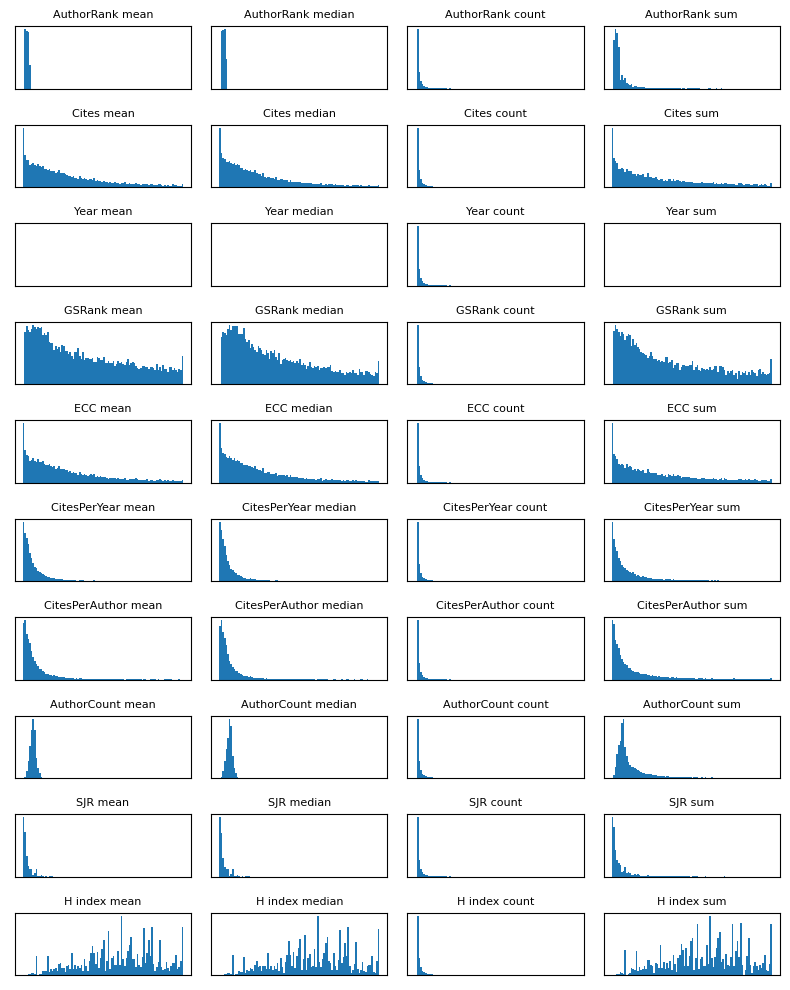

In [37]:
grouped_df = sub_df.groupby('AuthorName').agg(['mean', 'median', 'count', 'sum'])

level1_cols = sub_df.columns[1:]
level2_cols = ['mean', 'median', 'count', 'sum']

fig = plt.figure(figsize = (8, 10))
axes = fig.subplots(len(level1_cols), len(level2_cols))

i = 0 
for (row, col), ax in np.ndenumerate(axes):
    
    l1 = level1_cols[row]
    l2 = level2_cols[col]
    
    ax.hist(grouped_df[l1][l2], bins = 100, range = (0, 100))
    ax.set_title(f'{l1} {l2}', fontsize = 8)
    ax.set_xticks([],[])
    ax.set_yticks([],[])
    
    i += 1
    
fig.tight_layout()

It looks like, for the most part, the mean and median of each feature has a similar right-skew distribution as count and sum. The exceptions are `AuthorCount` and `AuthorRank` which have a move 'normal' distribution for the mean and median, and `Hindex` which has a more uniform distribution for mean, median and sum, but not count. For those reasons, for the final grouped dataset, let's chose to append the mean of the features for each author.

In [38]:
# Define new columns for the dataset
new_cols = np.asarray(['_'.join(['Mean', i]) for i in sub_df.groupby('AuthorName').mean().columns])
new_cols = ['AuthorName'] + np.where(new_cols == 'Mean_Hindex', 'Mean_SourceHindex', new_cols).tolist()

# Initiate new data frame
new_df2 = sub_df.groupby('AuthorName').mean().reset_index()

# Reset the columns names
new_df2.columns = new_cols

# Concat the Num column as well
new_df2 = pd.concat([new_df2, num_df.drop('AuthorName', axis= 1)], axis = 1)

new_df2.head()

,AuthorName,Mean_AuthorRank,Mean_Cites,Mean_Year,Mean_GSRank,Mean_ECC,Mean_CitesPerYear,Mean_CitesPerAuthor,Mean_AuthorCount,Mean_SJR,Mean_H index,NumPapers_inDataset
0,a aatiq,1.0,4.000000,2022.000000,3.000000,4.000000,4.000000,2.000000,2.000000,0.726000,89.00,1
1,a abate,1.0,57.624161,2017.013423,55.208054,57.624161,10.376242,10.630872,6.281879,2.816349,377.25,149
2,a abbas,1.0,8.000000,2010.500000,88.000000,8.000000,0.595000,1.500000,4.500000,0.566000,99.00,2
3,a abbasi,1.0,24.000000,2012.000000,17.000000,24.000000,2.180000,5.000000,5.000000,0.272000,77.00,1
4,a abdollahi,1.0,2.000000,2021.000000,174.000000,2.000000,1.000000,0.000000,10.000000,2.143000,255.00,1


In [16]:
def calculate_hindex(group):
    
    # An arr of the citations
    citations = group['Cites'].values.tolist()
    
    n = len(citations)
    citations.sort(reverse=True)
    h_index = 0
    
    for i in range(n):
        if citations[i] >= i+1:
            h_index = i+1
        else:
            break
    
    return h_index

In [39]:
grouped_df = sub_df.groupby('AuthorName')

# Get series of h index values
hindex_ser = grouped_df.apply(calculate_hindex).astype('int16').reset_index(name = 'Author_Hindex')

Let's add `Author_Hindex` to the data frame

In [43]:
new_df1 = pd.concat([new_df2, pd.DataFrame(hindex_ser).drop('AuthorName', axis = 1)], axis = 1)

In [44]:
new_df1.head()

,AuthorName,Mean_AuthorRank,Mean_Cites,Mean_Year,Mean_GSRank,Mean_ECC,Mean_CitesPerYear,Mean_CitesPerAuthor,Mean_AuthorCount,Mean_SJR,Mean_H index,NumPapers_inDataset,Author_Hindex
0,a aatiq,1.0,4.000000,2022.000000,3.000000,4.000000,4.000000,2.000000,2.000000,0.726000,89.00,1,1
1,a abate,1.0,57.624161,2017.013423,55.208054,57.624161,10.376242,10.630872,6.281879,2.816349,377.25,149,49
2,a abbas,1.0,8.000000,2010.500000,88.000000,8.000000,0.595000,1.500000,4.500000,0.566000,99.00,2,2
3,a abbasi,1.0,24.000000,2012.000000,17.000000,24.000000,2.180000,5.000000,5.000000,0.272000,77.00,1,1
4,a abdollahi,1.0,2.000000,2021.000000,174.000000,2.000000,1.000000,0.000000,10.000000,2.143000,255.00,1,1


In [45]:
new_df1.columns

Index(['AuthorName', 'Mean_AuthorRank', 'Mean_Cites', 'Mean_Year',
       'Mean_GSRank', 'Mean_ECC', 'Mean_CitesPerYear', 'Mean_CitesPerAuthor',
       'Mean_AuthorCount', 'Mean_SJR', 'Mean_H index', 'NumPapers_inDataset',
       'Author_Hindex'],
      dtype='object')

In [46]:
new_col = ['AuthorName', 'Mean_AuthorRank', 'Mean_Cites', 'Mean_Year',
       'Mean_GSRank', 'Mean_ECC', 'Mean_CitesPerYear', 'Mean_CitesPerAuthor',
       'Mean_AuthorCount', 'Mean_SJR', 'Mean_PubHindex', 'NumPapers_inDataset',
       'Author_Hindex']
new_df1.columns = new_col

In [52]:
new_df1.isna().sum()

AuthorName             0
Mean_AuthorRank        0
Mean_Cites             0
Mean_Year              0
Mean_GSRank            0
Mean_ECC               0
Mean_CitesPerYear      0
Mean_CitesPerAuthor    0
Mean_AuthorCount       0
Mean_SJR               0
Mean_PubHindex         0
NumPapers_inDataset    0
Author_Hindex          0
dtype: int64

Next, let's use `OneHotEncode` to generate columns for if each author is published in a specific journal or not. The encoded values will be stored in `encoded_df`

In [49]:
from sklearn.preprocessing import OneHotEncoder

# Instantiate the OneHotEncoder
ohe = OneHotEncoder()

# Fit the OneHotEncoder to the subcategory column and transform
# It expects a 2D array, so we first convert the column into a DataFrame
subcategory = pd.DataFrame(new_df['PubTitle'])
encoded = ohe.fit_transform(subcategory)

# Convert from sparse matrix to dense
dense_array = encoded.toarray()

# Define new Columns for the encoded array 
cols = ['In_' + i for i in ohe.categories_]

# Put into a dataframe to get column names
encoded_df = pd.DataFrame(dense_array, columns=cols, dtype=int)

# Show
encoded_df.head()

,In_accounts of chemical research,In_acs applied bio materials,In_acs applied electronic materials,In_acs applied energy materials,In_acs applied materials and interfaces,In_acs applied nano materials,In_acs applied polymer materials,In_acs biomaterials science and engineering,In_acs catalysis,In_acs central science,...,In_ultrasonics sonochemistry,In_vacuum,In_vakuum in forschung und praxis,In_water air and soil pollution,In_water research,In_wiley interdisciplinary reviews computational molecular science,In_wit transactions on ecology and the environment,In_world journal of engineering,In_wuli xuebaoacta physica sinica,In_xray spectrometry
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [53]:
encoded_df.group_

(59691, 912)

In [54]:
new_df1.shape

(16402, 13)

In [84]:
# fix formatting issues with the columns
encoded_df.columns, = ['In_' + i for i in ohe.categories_] 
encoded_df = encoded_df.astype('int16')

encodeSource_df = pd.concat([sub_df.loc[:, 'AuthorName'].reset_index(drop = True), encoded_df.reset_index(drop = True)], axis = 1)

In [88]:
new_en = encodeSource_df.groupby('AuthorName').agg('sum').astype('int16')

In [89]:
new_en.head(5)

,In_accounts of chemical research,In_acs applied bio materials,In_acs applied electronic materials,In_acs applied energy materials,In_acs applied materials and interfaces,In_acs applied nano materials,In_acs applied polymer materials,In_acs biomaterials science and engineering,In_acs catalysis,In_acs central science,...,In_ultrasonics sonochemistry,In_vacuum,In_vakuum in forschung und praxis,In_water air and soil pollution,In_water research,In_wiley interdisciplinary reviews computational molecular science,In_wit transactions on ecology and the environment,In_world journal of engineering,In_wuli xuebaoacta physica sinica,In_xray spectrometry
AuthorName,,,,,,,,,,,,,,,,,,,,,
a aatiq,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
a abate,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
a abbas,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
a abbasi,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
a abdollahi,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [90]:
new_df2 = pd.concat([new_df1.reset_index(drop = True), new_en.reset_index(drop = True)], axis = 1)

In [91]:
new_df2.head(5)

,AuthorName,Mean_AuthorRank,Mean_Cites,Mean_Year,Mean_GSRank,Mean_ECC,Mean_CitesPerYear,Mean_CitesPerAuthor,Mean_AuthorCount,Mean_SJR,...,In_ultrasonics sonochemistry,In_vacuum,In_vakuum in forschung und praxis,In_water air and soil pollution,In_water research,In_wiley interdisciplinary reviews computational molecular science,In_wit transactions on ecology and the environment,In_world journal of engineering,In_wuli xuebaoacta physica sinica,In_xray spectrometry
0,a aatiq,1.0,4.000000,2022.000000,3.000000,4.000000,4.000000,2.000000,2.000000,0.726000,...,0,0,0,0,0,0,0,0,0,0
1,a abate,1.0,57.624161,2017.013423,55.208054,57.624161,10.376242,10.630872,6.281879,2.816349,...,0,0,0,0,0,0,0,0,0,0
2,a abbas,1.0,8.000000,2010.500000,88.000000,8.000000,0.595000,1.500000,4.500000,0.566000,...,0,0,0,0,0,0,0,0,0,0
3,a abbasi,1.0,24.000000,2012.000000,17.000000,24.000000,2.180000,5.000000,5.000000,0.272000,...,0,0,0,0,0,0,0,0,0,0
4,a abdollahi,1.0,2.000000,2021.000000,174.000000,2.000000,1.000000,0.000000,10.000000,2.143000,...,0,0,0,0,0,0,0,0,0,0


In [92]:
new_df2.isna().sum().sum()

0

In [93]:
new_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16402 entries, 0 to 16401
Columns: 925 entries, AuthorName to In_xray spectrometry
dtypes: float16(1), float64(9), int16(913), int64(1), object(1)
memory usage: 30.0+ MB


In [103]:
np.max(new_df2.select_dtypes('number').loc[:, :'Author_Hindex'], axis = 0)

Mean_AuthorRank           4.000
Mean_Cites             6321.000
Mean_Year              2023.000
Mean_GSRank             992.000
Mean_ECC               6321.000
Mean_CitesPerYear       790.130
Mean_CitesPerAuthor     911.000
Mean_AuthorCount         12.000
Mean_SJR                 23.876
Mean_PubHindex         1276.000
NumPapers_inDataset     684.000
Author_Hindex           244.000
dtype: float64

In [120]:
new_df2.loc[:, 'Mean_AuthorRank':'Author_Hindex'] = new_df2.loc[:, 'Mean_AuthorRank':'Author_Hindex'].astype('float16')

In [121]:
new_df2.loc[:, 'NumPapers_inDataset':'Author_Hindex'] = new_df2.loc[:, 'NumPapers_inDataset':'Author_Hindex'].astype('int16')

In [122]:
new_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16402 entries, 0 to 16401
Columns: 925 entries, AuthorName to In_xray spectrometry
dtypes: float16(10), int16(914), object(1)
memory usage: 29.0+ MB


In [123]:
new_df2.sample(5)

,AuthorName,Mean_AuthorRank,Mean_Cites,Mean_Year,Mean_GSRank,Mean_ECC,Mean_CitesPerYear,Mean_CitesPerAuthor,Mean_AuthorCount,Mean_SJR,...,In_ultrasonics sonochemistry,In_vacuum,In_vakuum in forschung und praxis,In_water air and soil pollution,In_water research,In_wiley interdisciplinary reviews computational molecular science,In_wit transactions on ecology and the environment,In_world journal of engineering,In_wuli xuebaoacta physica sinica,In_xray spectrometry
11723,pf mndez,3.0,45.0,2000.0,34.000,45.0,1.959961,9.00,5.000,0.794922,...,0,0,0,0,0,0,0,0,0,0
3141,d dong,1.0,12.0,2019.0,31.000,12.0,3.000000,2.00,6.000,1.102539,...,0,0,0,0,0,0,0,0,0,0
13354,s nau,2.5,8.0,2018.0,111.000,8.0,1.500000,2.00,5.000,0.464111,...,0,0,0,0,0,0,0,0,0,0
886,a rivera,1.0,15.0,2019.0,88.375,15.0,3.357422,2.75,6.625,1.250977,...,0,0,0,0,0,0,0,0,0,0
428,a guagliardi,1.0,43.0,2017.0,18.000,43.0,7.171875,5.00,8.000,5.000000,...,0,0,0,0,0,0,0,0,0,0


In [124]:
author_df = new_df2.reset_index(drop = True)

In [125]:
author_df.to_pickle('2023-03-23_NB5_author_df.pkl')

----

Now let's group by `AuthorName` and aggregate the encoded columns by sum (so each column will have a sum of times an author is in a journal)

In [126]:
encodeSource_df.groupby('AuthorName').sum()

,In_accounts of chemical research,In_acs applied bio materials,In_acs applied electronic materials,In_acs applied energy materials,In_acs applied materials and interfaces,In_acs applied nano materials,In_acs applied polymer materials,In_acs biomaterials science and engineering,In_acs catalysis,In_acs central science,...,In_ultrasonics sonochemistry,In_vacuum,In_vakuum in forschung und praxis,In_water air and soil pollution,In_water research,In_wiley interdisciplinary reviews computational molecular science,In_wit transactions on ecology and the environment,In_world journal of engineering,In_wuli xuebaoacta physica sinica,In_xray spectrometry
AuthorName,,,,,,,,,,,,,,,,,,,,,
a aatiq,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
a abate,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
a abbas,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
a abbasi,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
a abdollahi,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zy xia,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
zy xiao,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
zy zhan,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Example slice of `In_journal of physical chemistry c`

In [98]:
encodeSource_df.groupby('AuthorName')['In_journal of physical chemistry c'].sum().sort_values()

AuthorName
a aatiq           0
n shinotsuka      0
n shirahata       0
n shirato         0
n sial            0
               ... 
ab tarasov       57
sv yakunin       64
di wu            73
j wongleung      89
mp ghimire      113
Name: In_journal of physical chemistry c, Length: 14165, dtype: int32

There looks like there are some spots of strong colliarities, mostlt between the journal encoders. However, since the goal is to build a reccomender system, we shouldn't have to worry about collinearities between endcoded journals. Let's keep them in for now and we can do back to them if necessary.

Let's save `new_df` as 'expanded_df' and `new_df7` as 'grouped_df'

In [4]:
input_df = pd.read_pickle('2023-03-23_NB5_author_df.pkl')

In [20]:
input_df['AuthorName'].str.rsplit(' ')

0            [a, aatiq]
1            [a, abate]
2            [a, abbas]
3           [a, abbasi]
4        [a, abdollahi]
              ...      
16397         [zy, xia]
16398        [zy, xiao]
16399        [zy, zhan]
16400         [zz, dai]
16401          [zz, ma]
Name: AuthorName, Length: 16402, dtype: object

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Initiate 
bagofwords = CountVectorizer(stop_words = 'english')

bagofwords.fit(input_df['AuthorName'])

small_transformed = bagofwords.transform(input_df['AuthorName'])

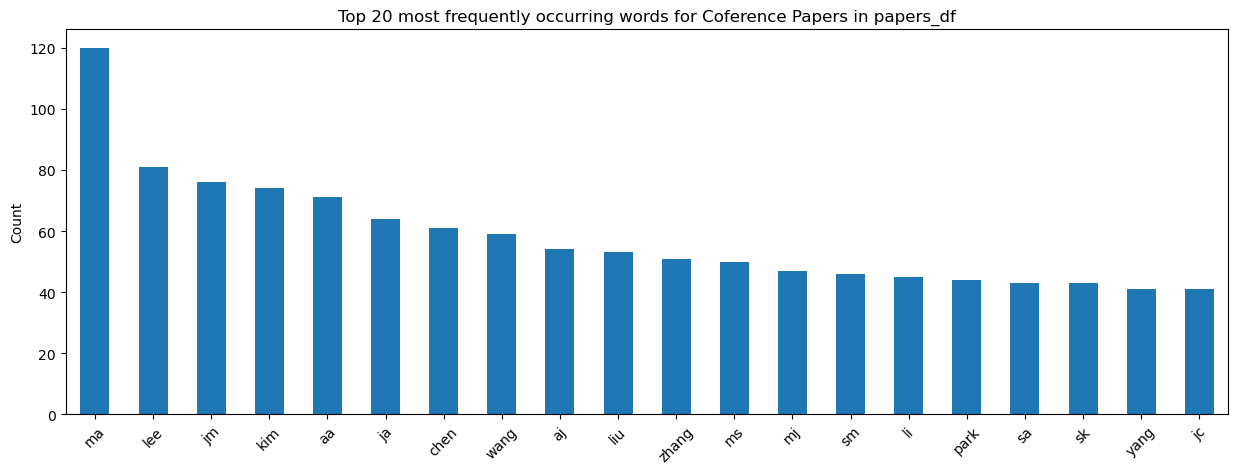

In [14]:
word_counts = pd.DataFrame(
    {"counts": small_transformed.toarray().sum(axis=0)},
    index=bagofwords.get_feature_names_out()
).sort_values("counts", ascending=False)

word_counts.head(20).plot(kind="bar", figsize=(15, 5), legend=False)
plt.title("Top 20 most frequently occurring words for Coference Papers in papers_df")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

---